# Regime-Dependent Prediction under Financial Market Uncertainty

**A GitHub-ready machine learning research notebook**  
This notebook upgrades a standard stock-price prediction project into a research-oriented project on **uncertainty-aware predictive decision-making**.

The central research question is:

> Can machine learning models provide stable directional predictions across different market regimes, or does predictive reliability deteriorate when market uncertainty changes?

This version is designed to be clean enough to show on GitHub and strong enough to discuss in an Operations Management / Operations Research PhD application context.

## Project Contributions

This notebook extends the original project in five research-oriented ways:

1. **LSTM volatility proxy**: uses recent return sequences to estimate forward-looking uncertainty. If TensorFlow is unavailable, the notebook automatically falls back to EWMA volatility.
2. **Regime-specific performance comparison**: evaluates whether model performance differs across low-, medium-, and high-volatility regimes.
3. **Overfitting detection**: compares train and test accuracy and reports the generalization gap.
4. **Random-walk and naive benchmarks**: compares ML models against majority-class and persistence/random-walk baselines.
5. **Rolling-window validation**: tests whether model performance is stable across different historical windows.

The goal is not simply to maximize prediction accuracy. The goal is to evaluate **model reliability under uncertainty and non-stationarity**, which is a stronger research framing for PhD applications.

## How to Use This Notebook

### Option A: Use your real data
Place a CSV file in the repository root or a `data/` folder. The notebook will search for common filenames such as:

- `feature_futures_5min.csv`
- `data/feature_futures_5min.csv`
- `market_data.csv`
- `data/market_data.csv`

Your dataset should contain either:

- a `ret` column, or
- a price column such as `Close`, `Price`, or `close`.

Optional columns such as `Volume`, `Open`, `High`, `Low`, `Vwap`, and other asset returns will be used when available.

### Option B: Run without data
If no CSV is found, the notebook creates a synthetic market-like dataset so the full pipeline can still run end-to-end. This is useful for GitHub reviewers who want to verify the code structure.

In [1]:
# ============================================================
# 1. Imports and Global Configuration
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# GitHub-friendly settings
USE_SYNTHETIC_IF_NO_DATA = True
SAVE_OUTPUTS = True
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

# Candidate data paths. Edit this list if your data is stored elsewhere.
DATA_PATHS = [
    Path("feature_futures_5min.csv"),
    Path("data/feature_futures_5min.csv"),
    Path("market_data.csv"),
    Path("data/market_data.csv"),
]

print("Notebook initialized.")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(f"Figure directory: {FIGURE_DIR.resolve()}")

Notebook initialized.
Output directory: /mnt/data/outputs


## 2. Data Loading

The data loader is intentionally flexible. It first searches for local CSV files. If no file exists, it generates synthetic data so the notebook remains runnable for GitHub demonstration purposes.

In [2]:
# ============================================================
# 2. Data Loading Utilities
# ============================================================

def generate_synthetic_market_data(n=3000, seed=RANDOM_STATE):
    """
    Generate market-like intraday data with volatility clustering.
    This is only a fallback so the notebook can run without proprietary data.
    Replace it with real market data for actual analysis.
    """
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2021-01-04 09:30", periods=n, freq="5min")

    # Three hidden volatility states to mimic regime changes
    regimes = rng.choice([0, 1, 2], size=n, p=[0.55, 0.30, 0.15])
    sigma = np.select([regimes == 0, regimes == 1, regimes == 2], [0.0006, 0.0012, 0.0024])

    # Mild autocorrelation plus noise
    ret = np.zeros(n)
    noise = rng.normal(0, sigma)
    for t in range(1, n):
        ret[t] = 0.08 * ret[t - 1] + noise[t]

    close = 4500 * np.exp(np.cumsum(ret))
    volume = rng.lognormal(mean=10.5, sigma=0.45, size=n).astype(int)
    high = close * (1 + np.abs(rng.normal(0, sigma * 0.8)))
    low = close * (1 - np.abs(rng.normal(0, sigma * 0.8)))
    open_ = close / (1 + ret)
    vwap = (open_ + high + low + close) / 4

    # Cross-asset proxy features
    vix_ret = np.abs(ret) * 2 + rng.normal(0, 0.001, n)
    crude_ret = 0.20 * ret + rng.normal(0, 0.0012, n)
    gold_ret = -0.10 * ret + rng.normal(0, 0.0009, n)

    df = pd.DataFrame({
        "Open": open_,
        "High": high,
        "Low": low,
        "Close": close,
        "Volume": volume,
        "Vwap": vwap,
        "ret": ret,
        "VIX_ret": vix_ret,
        "Crude_ret": crude_ret,
        "Gold_ret": gold_ret,
    }, index=idx)
    df.index.name = "DateTime"
    return df


def load_market_data(paths=DATA_PATHS, use_synthetic=USE_SYNTHETIC_IF_NO_DATA):
    """
    Load market data from local CSV files. If no file is found, optionally use synthetic data.
    """
    for path in paths:
        if path.exists():
            df = pd.read_csv(path)
            print(f"Loaded data from: {path}")

            # Try to infer datetime index
            datetime_candidates = ["DateTime", "Datetime", "datetime", "Date", "date", "Time", "time"]
            for col in datetime_candidates:
                if col in df.columns:
                    df[col] = pd.to_datetime(df[col], errors="coerce")
                    if df[col].notna().mean() > 0.80:
                        df = df.set_index(col).sort_index()
                    break
            return df

    if use_synthetic:
        print("No local CSV found. Using synthetic market-like data for reproducibility demo.")
        return generate_synthetic_market_data()

    raise FileNotFoundError("No data file found. Please add a CSV file or enable synthetic fallback.")

raw_data = load_market_data()
raw_data.head()

No local CSV found. Using synthetic market-like data for reproducibility demo.


,Open,High,Low,Close,Volume,Vwap,ret,VIX_ret,Crude_ret,Gold_ret
DateTime,,,,,,,,,,
2021-01-04 09:30:00,4500.000000,4501.420299,4497.674796,4500.000000,35988,4499.773774,0.000000,-0.000162,-0.001308,0.001061
2021-01-04 09:35:00,4500.000462,4501.445492,4495.834855,4497.961369,17802,4498.810545,-0.000453,0.000157,-0.000365,0.001977
2021-01-04 09:40:00,4498.060102,4477.367705,4453.299983,4468.322842,21534,4474.262658,-0.006611,0.013027,-0.002252,0.000379
2021-01-04 09:45:00,4468.338550,4463.520740,4454.520260,4456.500828,21923,4460.720095,-0.002649,0.005073,-0.001586,-0.000925
2021-01-04 09:50:00,4456.501743,4462.251072,4457.489157,4459.358524,51218,4458.900124,0.000641,0.002236,0.002163,-0.000275


## 3. Feature Engineering

This section creates research features related to return dynamics, volatility, volume, trend, and market microstructure. It also creates the target variable: whether the next-period return is positive.

In [3]:
# ============================================================
# 3. Feature Engineering
# ============================================================

def infer_return_column(df):
    """
    Ensure the dataset has a return column named 'ret'.
    """
    out = df.copy()
    if "ret" in out.columns:
        out["ret"] = pd.to_numeric(out["ret"], errors="coerce")
        return out

    price_candidates = ["Close", "close", "Price", "price", "Last", "last"]
    for col in price_candidates:
        if col in out.columns:
            out["ret"] = pd.to_numeric(out[col], errors="coerce").pct_change()
            return out

    raise ValueError("Dataset must contain either a 'ret' column or a price column such as 'Close' or 'Price'.")


def engineer_features(df):
    """
    Create a clean modeling dataset.
    The target is next-period directional movement.
    """
    out = infer_return_column(df)
    out = out.replace([np.inf, -np.inf], np.nan).sort_index()

    # Core lagged return features
    for lag in [1, 2, 3, 6, 12, 24]:
        out[f"ret_lag_{lag}"] = out["ret"].shift(lag)

    # Rolling statistical features
    for window in [6, 12, 24, 72]:
        out[f"rolling_mean_ret_{window}"] = out["ret"].rolling(window).mean()
        out[f"rolling_std_ret_{window}"] = out["ret"].rolling(window).std()
        out[f"rolling_skew_ret_{window}"] = out["ret"].rolling(window).skew()
        out[f"rolling_abs_ret_{window}"] = out["ret"].abs().rolling(window).mean()

    # Price-based features, when available
    if "Close" in out.columns:
        close = pd.to_numeric(out["Close"], errors="coerce")
        for window in [6, 12, 24, 72]:
            out[f"close_momentum_{window}"] = close.pct_change(window)
            out[f"close_ma_ratio_{window}"] = close / close.rolling(window).mean() - 1

    # Range and volume features, when available
    if {"High", "Low", "Close"}.issubset(out.columns):
        out["range_pct"] = (out["High"] - out["Low"]) / out["Close"]
        out["range_pct_lag_1"] = out["range_pct"].shift(1)

    if "Volume" in out.columns:
        volume = pd.to_numeric(out["Volume"], errors="coerce")
        out["volume_log"] = np.log1p(volume)
        out["volume_z_72"] = (volume - volume.rolling(72).mean()) / volume.rolling(72).std()
        out["volume_change"] = volume.pct_change().replace([np.inf, -np.inf], np.nan)

    # Target: next-period direction
    out["target_return"] = out["ret"].shift(-1)
    out["target_direction"] = (out["target_return"] > 0).astype(int)

    return out

feature_data = engineer_features(raw_data)
feature_data.head()

,Open,High,Low,Close,Volume,Vwap,ret,VIX_ret,Crude_ret,Gold_ret,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_6,ret_lag_12,ret_lag_24,rolling_mean_ret_6,rolling_std_ret_6,rolling_skew_ret_6,rolling_abs_ret_6,rolling_mean_ret_12,rolling_std_ret_12,rolling_skew_ret_12,rolling_abs_ret_12,rolling_mean_ret_24,rolling_std_ret_24,rolling_skew_ret_24,rolling_abs_ret_24,rolling_mean_ret_72,rolling_std_ret_72,rolling_skew_ret_72,rolling_abs_ret_72,close_momentum_6,close_ma_ratio_6,close_momentum_12,close_ma_ratio_12,close_momentum_24,close_ma_ratio_24,close_momentum_72,close_ma_ratio_72,range_pct,range_pct_lag_1,volume_log,volume_z_72,volume_change,target_return,target_direction
DateTime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:30:00,4500.000000,4501.420299,4497.674796,4500.000000,35988,4499.773774,0.000000,-0.000162,-0.001308,0.001061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000832,NaN,10.490969,NaN,NaN,-0.000453,0
2021-01-04 09:35:00,4500.000462,4501.445492,4495.834855,4497.961369,17802,4498.810545,-0.000453,0.000157,-0.000365,0.001977,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001247,0.000832,9.787122,NaN,-0.505335,-0.006611,0
2021-01-04 09:40:00,4498.060102,4477.367705,4453.299983,4468.322842,21534,4474.262658,-0.006611,0.013027,-0.002252,0.000379,-0.000453,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005386,0.001247,9.977435,NaN,0.209639,-0.002649,0
2021-01-04 09:45:00,4468.338550,4463.520740,4454.520260,4456.500828,21923,4460.720095,-0.002649,0.005073,-0.001586,-0.000925,-0.006611,-0.000453,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002020,0.005386,9.995337,NaN,0.018064,0.000641,1
2021-01-04 09:50:00,4456.501743,4462.251072,4457.489157,4459.358524,51218,4458.900124,0.000641,0.002236,0.002163,-0.000275,-0.002649,-0.006611,-0.000453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001068,0.002020,10.843866,NaN,1.336268,-0.000912,0


## 4. LSTM Volatility Proxy

This section estimates an uncertainty proxy from recent return sequences. The LSTM is optional because GitHub or local environments may not have TensorFlow installed. If TensorFlow is unavailable, the code automatically uses EWMA volatility as a robust fallback.

In [4]:
# ============================================================
# 4. LSTM Volatility Proxy with EWMA Fallback
# ============================================================

def add_lstm_volatility_proxy(df, ret_col="ret", lookback=24, epochs=6, batch_size=64):
    """
    Add a sequence-based volatility proxy.

    Primary approach:
        LSTM uses the past `lookback` returns to predict next-period absolute return.

    Fallback approach:
        If TensorFlow is unavailable or the sample is too small, use EWMA volatility.
    """
    out = df.copy()
    out["ewma_volatility"] = out[ret_col].ewm(span=lookback, adjust=False).std()
    out["rolling_volatility"] = out[ret_col].rolling(lookback).std()
    out["lstm_volatility_proxy"] = np.nan

    returns = out[ret_col].astype(float).to_numpy()
    target_abs_ret = np.abs(out[ret_col].shift(-1).astype(float).to_numpy())

    X_seq, y_seq, idx_seq = [], [], []
    for i in range(lookback, len(out) - 1):
        window = returns[i - lookback:i]
        if np.any(pd.isna(window)) or pd.isna(target_abs_ret[i]):
            continue
        X_seq.append(window.reshape(-1, 1))
        y_seq.append(target_abs_ret[i])
        idx_seq.append(out.index[i])

    try:
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras.callbacks import EarlyStopping

        X_seq = np.asarray(X_seq)
        y_seq = np.asarray(y_seq)

        if len(X_seq) < 250:
            raise ValueError("Not enough observations for LSTM training.")

        split = int(len(X_seq) * 0.70)
        X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
        y_train_seq = y_seq[:split]
        idx_test_seq = idx_seq[split:]

        scaler = StandardScaler()
        scaler.fit(X_train_seq.reshape(-1, 1))
        X_train_scaled = scaler.transform(X_train_seq.reshape(-1, 1)).reshape(X_train_seq.shape)
        X_test_scaled = scaler.transform(X_test_seq.reshape(-1, 1)).reshape(X_test_seq.shape)

        model = Sequential([
            LSTM(16, input_shape=(lookback, 1), return_sequences=False),
            Dropout(0.20),
            Dense(8, activation="relu"),
            Dense(1),
        ])
        model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
        early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

        model.fit(
            X_train_scaled,
            y_train_seq,
            validation_split=0.20,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0,
        )

        pred_vol = model.predict(X_test_scaled, verbose=0).reshape(-1)
        out.loc[idx_test_seq, "lstm_volatility_proxy"] = pred_vol
        out["volatility_proxy_source"] = "LSTM_with_EWMA_fill"
        print("LSTM volatility proxy created. Missing early values will be filled with EWMA volatility.")

    except Exception as exc:
        print(f"TensorFlow/LSTM unavailable or skipped: {exc}")
        print("Using EWMA volatility as the volatility proxy.")
        out["volatility_proxy_source"] = "EWMA_fallback"

    out["lstm_volatility_proxy"] = out["lstm_volatility_proxy"].fillna(out["ewma_volatility"])
    return out

feature_data = add_lstm_volatility_proxy(feature_data)
feature_data[["ret", "ewma_volatility", "rolling_volatility", "lstm_volatility_proxy", "volatility_proxy_source"]].tail()

TensorFlow/LSTM unavailable or skipped: No module named 'tensorflow'
Using EWMA volatility as the volatility proxy.


,ret,ewma_volatility,rolling_volatility,lstm_volatility_proxy,volatility_proxy_source
DateTime,,,,,
2021-01-14 19:05:00,0.000440,0.001133,0.001049,0.001133,EWMA_fallback
2021-01-14 19:10:00,0.000242,0.001087,0.001046,0.001087,EWMA_fallback
2021-01-14 19:15:00,0.000337,0.001043,0.001045,0.001043,EWMA_fallback
2021-01-14 19:20:00,-0.001634,0.001137,0.001110,0.001137,EWMA_fallback
2021-01-14 19:25:00,-0.000277,0.001098,0.001112,0.001098,EWMA_fallback


## 5. Market Regime Construction

The notebook creates two regime definitions:

1. **Volatility quantile regimes**: low, medium, and high volatility based on the volatility proxy.
2. **Gaussian Mixture regimes**: unsupervised regimes based on return and volatility features.

The quantile regime is used as the primary interpretation layer because it is transparent and easy to explain.

In [5]:
# ============================================================
# 5. Regime Construction
# ============================================================

def add_market_regimes(df, vol_col="lstm_volatility_proxy", n_components=3):
    """
    Add transparent volatility regimes and unsupervised Gaussian mixture regimes.
    """
    out = df.copy()

    # Transparent quantile-based regimes
    valid_vol = out[vol_col].replace([np.inf, -np.inf], np.nan)
    out["volatility_regime"] = pd.qcut(
        valid_vol.rank(method="first"),
        q=3,
        labels=["Low volatility", "Medium volatility", "High volatility"],
    )

    # GMM regimes based on return and volatility-related variables
    gmm_cols = ["ret", vol_col, "rolling_std_ret_24", "rolling_abs_ret_24"]
    gmm_cols = [col for col in gmm_cols if col in out.columns]
    gmm_input = out[gmm_cols].replace([np.inf, -np.inf], np.nan).dropna()

    out["gmm_regime"] = np.nan
    if len(gmm_input) >= 200 and len(gmm_cols) >= 2:
        scaler = StandardScaler()
        X_gmm = scaler.fit_transform(gmm_input)
        gmm = GaussianMixture(n_components=n_components, random_state=RANDOM_STATE)
        out.loc[gmm_input.index, "gmm_regime"] = gmm.fit_predict(X_gmm)

    return out

feature_data = add_market_regimes(feature_data)
feature_data[["ret", "lstm_volatility_proxy", "volatility_regime", "gmm_regime"]].dropna().head()

,ret,lstm_volatility_proxy,volatility_regime,gmm_regime
DateTime,,,,
2021-01-04 11:25:00,0.001070,0.001584,High volatility,1.0
2021-01-04 11:30:00,0.000222,0.001525,High volatility,1.0
2021-01-04 11:35:00,0.000128,0.001465,High volatility,1.0
2021-01-04 11:40:00,0.001181,0.001460,High volatility,2.0
2021-01-04 11:45:00,-0.000667,0.001406,High volatility,2.0


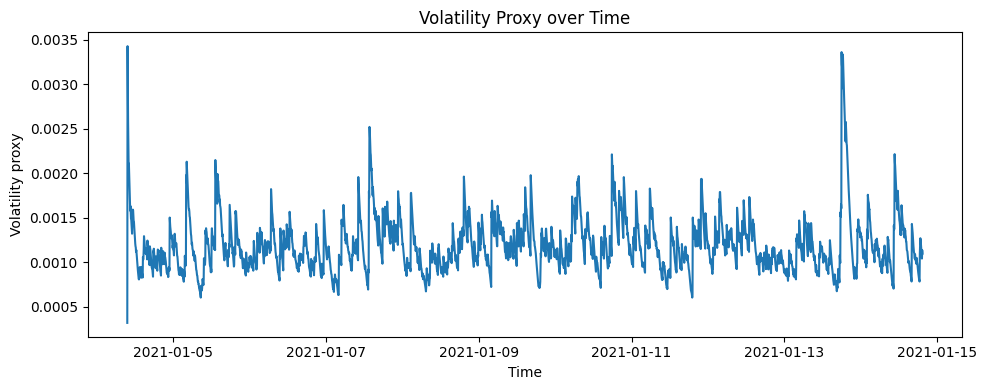

,observations,avg_return,return_std,avg_volatility_proxy
volatility_regime,,,,
Low volatility,1000,0.000025,0.000724,0.000920
Medium volatility,999,-0.000028,0.001047,0.001144
High volatility,1000,0.000035,0.001716,0.001514


In [6]:
# Quick visualization of uncertainty regimes
plot_df = feature_data[["lstm_volatility_proxy", "volatility_regime"]].dropna().copy()

plt.figure(figsize=(10, 4))
plt.plot(plot_df.index, plot_df["lstm_volatility_proxy"])
plt.title("Volatility Proxy over Time")
plt.xlabel("Time")
plt.ylabel("Volatility proxy")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "volatility_proxy_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

regime_summary = feature_data.groupby("volatility_regime", observed=False).agg(
    observations=("ret", "count"),
    avg_return=("ret", "mean"),
    return_std=("ret", "std"),
    avg_volatility_proxy=("lstm_volatility_proxy", "mean"),
)
regime_summary


## 6. Modeling Dataset

We build a clean feature matrix and preserve chronological order. This is important because random train-test splits can leak future information in time-series data.

In [7]:
# ============================================================
# 6. Modeling Dataset
# ============================================================

def build_modeling_dataset(df):
    """
    Select numeric features, remove leakage columns, and return clean modeling data.
    """
    out = df.copy().replace([np.inf, -np.inf], np.nan)

    leakage_cols = {
        "target_return",
        "target_direction",
        "volatility_proxy_source",
    }

    # Exclude raw future target and non-numeric variables. Keep regimes separately for analysis.
    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [
        col for col in numeric_cols
        if col not in leakage_cols
        and not col.lower().startswith("target")
        and col not in ["gmm_regime"]
    ]

    # Avoid using contemporaneous raw Close-like price level if available; derived features are more stable.
    for raw_price_col in ["Open", "High", "Low", "Close", "Price", "Vwap"]:
        if raw_price_col in feature_cols:
            feature_cols.remove(raw_price_col)

    required_cols = list(dict.fromkeys(feature_cols + ["target_direction", "ret", "volatility_regime"]))
    model_data = out[required_cols].dropna().copy()

    return model_data, feature_cols

model_data, feature_cols = build_modeling_dataset(feature_data)

print(f"Modeling observations: {len(model_data):,}")
print(f"Number of model features: {len(feature_cols)}")
print("First 15 features:", feature_cols[:15])
model_data.head()

Modeling observations: 2,928
Number of model features: 43
First 15 features: ['Volume', 'ret', 'VIX_ret', 'Crude_ret', 'Gold_ret', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_6', 'ret_lag_12', 'ret_lag_24', 'rolling_mean_ret_6', 'rolling_std_ret_6', 'rolling_skew_ret_6', 'rolling_abs_ret_6']


,Volume,ret,VIX_ret,Crude_ret,Gold_ret,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_6,ret_lag_12,ret_lag_24,rolling_mean_ret_6,rolling_std_ret_6,rolling_skew_ret_6,rolling_abs_ret_6,rolling_mean_ret_12,rolling_std_ret_12,rolling_skew_ret_12,rolling_abs_ret_12,rolling_mean_ret_24,rolling_std_ret_24,rolling_skew_ret_24,rolling_abs_ret_24,rolling_mean_ret_72,rolling_std_ret_72,rolling_skew_ret_72,rolling_abs_ret_72,close_momentum_6,close_ma_ratio_6,close_momentum_12,close_ma_ratio_12,close_momentum_24,close_ma_ratio_24,close_momentum_72,close_ma_ratio_72,range_pct,range_pct_lag_1,volume_log,volume_z_72,volume_change,ewma_volatility,rolling_volatility,lstm_volatility_proxy,target_direction,volatility_regime
DateTime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-04 15:30:00,46414,-0.001128,0.002534,0.000124,0.000747,-0.000226,-0.000831,0.001217,-0.000305,0.002872,0.001858,0.000038,0.000920,-0.082790,0.000766,0.000107,0.001205,0.723924,0.000941,0.000346,0.001121,0.614414,0.000878,0.000025,0.001346,-1.710053,0.000890,0.000228,-0.001022,0.001284,0.000211,0.008338,0.003411,0.001816,0.007873,0.006692,0.000657,10.745378,0.328754,3.899092,0.001126,0.001121,0.001126,0,Medium volatility
2021-01-04 15:35:00,23119,-0.001274,0.002957,-0.000138,-0.000026,-0.001128,-0.000226,-0.000831,0.000725,-0.000061,0.000031,-0.000295,0.000982,0.710141,0.000858,0.000006,0.001270,0.766078,0.001042,0.000292,0.001168,0.570584,0.000930,0.000014,0.001354,-1.667707,0.000902,-0.001770,-0.002000,0.000070,-0.001069,0.007022,0.001841,0.000993,0.006575,0.000929,0.006692,10.048453,-0.724072,-0.501896,0.001158,0.001168,0.001158,1,Medium volatility
2021-01-04 15:40:00,19153,0.000534,0.001544,0.000832,-0.000205,-0.001274,-0.001128,-0.000226,0.000471,-0.000925,0.000158,-0.000285,0.000992,0.677666,0.000869,0.000127,0.001242,0.519055,0.001009,0.000307,0.001169,0.526230,0.000945,0.000113,0.001099,-0.221407,0.000817,-0.001707,-0.001182,0.001530,-0.000662,0.007401,0.002069,0.008171,0.006999,0.000768,0.000929,9.860267,-0.900264,-0.171547,0.001117,0.001169,0.001117,0,Medium volatility
2021-01-04 15:45:00,33362,-0.000119,-0.001165,-0.001374,0.001346,0.000534,-0.001274,-0.001128,0.001217,-0.001526,-0.000780,-0.000507,0.000692,0.441153,0.000686,0.000245,0.001133,0.646766,0.000892,0.000335,0.001150,0.512227,0.000918,0.000148,0.001049,-0.093787,0.000782,-0.003040,-0.000794,0.002940,-0.001025,0.008066,0.001615,0.010725,0.006729,0.001519,0.000768,10.415203,-0.268538,0.741868,0.001074,0.001150,0.001074,1,Medium volatility
2021-01-04 15:50:00,43692,0.000434,0.000078,0.000563,-0.000893,-0.000119,0.000534,-0.001274,-0.000831,0.002675,-0.000599,-0.000297,0.000763,-0.365557,0.000619,0.000058,0.000844,-0.225724,0.000705,0.000378,0.001132,0.438162,0.000911,0.000145,0.001048,-0.086833,0.000779,-0.001778,-0.000064,0.000695,-0.000649,0.009108,0.001672,0.010516,0.007020,0.001360,0.001519,10.684943,0.203529,0.309634,0.001034,0.001132,0.001034,1,Low volatility


## 7. Chronological Train-Test Split

A chronological split better reflects the real forecasting problem: models are trained on past data and evaluated on future data.

In [8]:
# ============================================================
# 7. Chronological Train-Test Split
# ============================================================

def chronological_train_test_split(df, test_size=0.30):
    split = int(len(df) * (1 - test_size))
    train = df.iloc[:split].copy()
    test = df.iloc[split:].copy()
    return train, test

train_df, test_df = chronological_train_test_split(model_data, test_size=0.30)

print(f"Train period: {train_df.index.min()} to {train_df.index.max()} | n={len(train_df):,}")
print(f"Test period:  {test_df.index.min()} to {test_df.index.max()} | n={len(test_df):,}")
print("Target class balance in test set:")
print(test_df["target_direction"].value_counts(normalize=True).rename("share"))

Train period: 2021-01-04 15:30:00 to 2021-01-11 18:10:00 | n=2,049
Test period:  2021-01-11 18:15:00 to 2021-01-14 19:25:00 | n=879
Target class balance in test set:
target_direction
1    0.540387
0    0.459613
Name: share, dtype: float64


## 8. Benchmarks

A model is only useful if it beats simple benchmarks. This notebook uses two baselines:

1. **Majority-class baseline**: always predicts the most frequent direction in the training data.
2. **Random-walk / persistence baseline**: predicts that the next direction will match the most recent observed direction.

In [9]:
# ============================================================
# 8. Metrics and Benchmarks
# ============================================================

def classification_metrics(y_true, y_pred, y_score=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_score)
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def evaluate_baselines(train, test):
    majority_class = int(train["target_direction"].mode().iloc[0])
    majority_pred = np.repeat(majority_class, len(test))

    # Persistence/random-walk baseline: next direction equals current direction.
    # Since target_direction at t is direction of ret at t+1, we use observed ret at t.
    persistence_pred = (test["ret"] > 0).astype(int).to_numpy()

    rows = []
    for name, pred in [
        ("Majority Class Benchmark", majority_pred),
        ("Random-Walk Persistence Benchmark", persistence_pred),
    ]:
        row = {"model": name}
        row.update(classification_metrics(test["target_direction"], pred))
        rows.append(row)
    return pd.DataFrame(rows)

baseline_results = evaluate_baselines(train_df, test_df)
baseline_results

,model,accuracy,balanced_accuracy,f1,roc_auc
0,Majority Class Benchmark,0.459613,0.500000,0.000000,NaN
1,Random-Walk Persistence Benchmark,0.576792,0.574013,0.608421,NaN


## 9. Machine Learning Models

The model set is intentionally interpretable and appropriate for an applied research project:

- Logistic Regression: linear baseline with standardized features.
- Decision Tree: nonlinear but interpretable model.
- Random Forest: stronger nonlinear ensemble model.

In [10]:
# ============================================================
# 9. Model Training and Evaluation
# ============================================================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}


def fit_and_evaluate_models(train, test, feature_cols, models):
    X_train = train[feature_cols]
    y_train = train["target_direction"]
    X_test = test[feature_cols]
    y_test = test["target_direction"]

    rows = []
    fitted_models = {}

    for name, model in models.items():
        clf = clone(model)
        clf.fit(X_train, y_train)
        fitted_models[name] = clf

        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)
        test_score = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None

        row = {"model": name}
        row["train_accuracy"] = accuracy_score(y_train, train_pred)
        test_metrics = classification_metrics(y_test, test_pred, test_score)
        row.update({f"test_{k}": v for k, v in test_metrics.items()})
        row["overfitting_gap"] = row["train_accuracy"] - row["test_accuracy"]
        rows.append(row)

    results = pd.DataFrame(rows).sort_values("test_balanced_accuracy", ascending=False)
    return results, fitted_models

model_results, fitted_models = fit_and_evaluate_models(train_df, test_df, feature_cols, models)

combined_results = pd.concat([
    baseline_results.assign(train_accuracy=np.nan, overfitting_gap=np.nan).rename(columns={
        "accuracy": "test_accuracy",
        "balanced_accuracy": "test_balanced_accuracy",
        "f1": "test_f1",
        "roc_auc": "test_roc_auc",
    }),
    model_results,
], ignore_index=True)

combined_results = combined_results[[
    "model",
    "train_accuracy",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_f1",
    "test_roc_auc",
    "overfitting_gap",
]]
combined_results

,model,train_accuracy,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,overfitting_gap
0,Majority Class Benchmark,NaN,0.459613,0.500000,0.000000,NaN,NaN
1,Random-Walk Persistence Benchmark,NaN,0.576792,0.574013,0.608421,NaN,NaN
2,Logistic Regression,0.572474,0.549488,0.548564,0.573276,0.557910,0.022986
3,Random Forest,0.749146,0.541524,0.537496,0.580645,0.552314,0.207621
4,Decision Tree,0.623231,0.526735,0.518817,0.584830,0.509622,0.096496


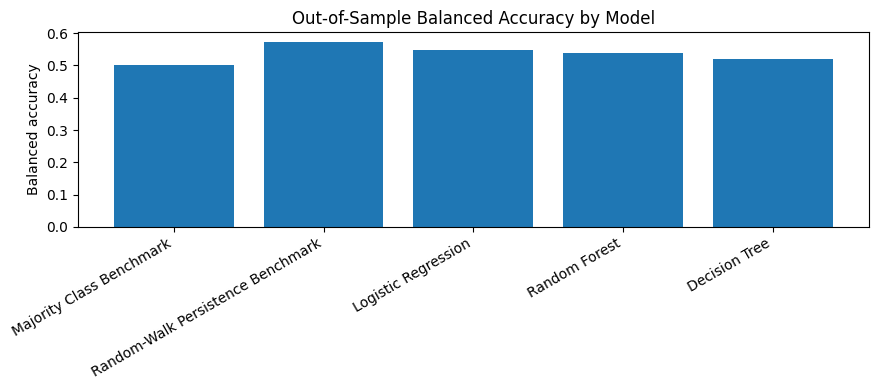

In [11]:
if SAVE_OUTPUTS:
    combined_results.to_csv(OUTPUT_DIR / "model_performance_summary.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(combined_results["model"], combined_results["test_balanced_accuracy"])
plt.title("Out-of-Sample Balanced Accuracy by Model")
plt.ylabel("Balanced accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_DIR / 'model_performance_comparison.png'}")


## 10. Overfitting Detection

This section explicitly checks whether stronger models achieve high training accuracy but fail to generalize out of sample.

In [12]:
# ============================================================
# 10. Overfitting Detection
# ============================================================

overfitting_report = model_results[[
    "model",
    "train_accuracy",
    "test_accuracy",
    "overfitting_gap",
]].copy()

overfitting_report["interpretation"] = np.where(
    overfitting_report["overfitting_gap"] > 0.10,
    "Potential overfitting: large train-test gap",
    "No severe overfitting detected by this threshold",
)

overfitting_report

,model,train_accuracy,test_accuracy,overfitting_gap,interpretation
0,Logistic Regression,0.572474,0.549488,0.022986,No severe overfitting detected by this threshold
2,Random Forest,0.749146,0.541524,0.207621,Potential overfitting: large train-test gap
1,Decision Tree,0.623231,0.526735,0.096496,No severe overfitting detected by this threshold


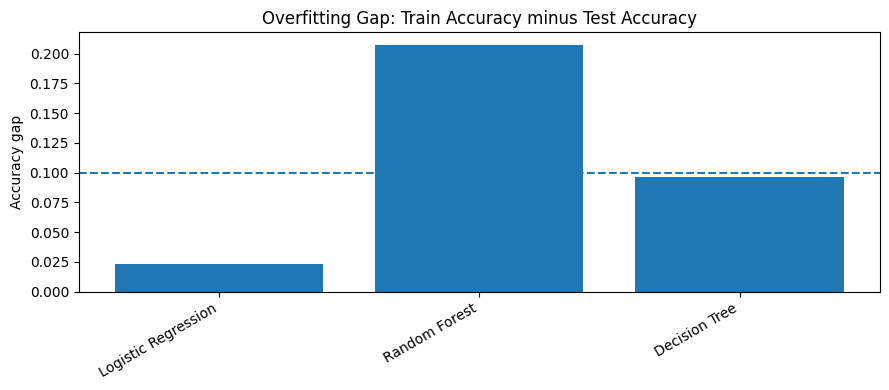

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(overfitting_report["model"], overfitting_report["overfitting_gap"])
plt.axhline(0.10, linestyle="--", label="Potential overfitting threshold")
plt.title("Overfitting Gap: Train Accuracy minus Test Accuracy")
plt.ylabel("Accuracy gap")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "overfitting_gap.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_DIR / 'overfitting_gap.png'}")


## 11. Regime-Specific Performance Comparison

This is the key research extension. Instead of asking only whether a model works on average, we ask:

> Does the model remain reliable when uncertainty changes?

This is a stronger PhD-style research question because it evaluates robustness across heterogeneous operating conditions.

In [14]:
# ============================================================
# 11. Regime-Specific Performance Comparison
# ============================================================

def regime_specific_performance(test, feature_cols, fitted_models):
    rows = []
    for regime, subset in test.groupby("volatility_regime", observed=False):
        if len(subset) < 20:
            continue

        # Benchmarks within each regime
        majority_pred = np.repeat(int(train_df["target_direction"].mode().iloc[0]), len(subset))
        persistence_pred = (subset["ret"] > 0).astype(int).to_numpy()

        for name, pred in [
            ("Majority Class Benchmark", majority_pred),
            ("Random-Walk Persistence Benchmark", persistence_pred),
        ]:
            row = {"regime": regime, "model": name, "observations": len(subset)}
            row.update(classification_metrics(subset["target_direction"], pred))
            rows.append(row)

        # ML models within each regime
        X_regime = subset[feature_cols]
        y_regime = subset["target_direction"]
        for name, clf in fitted_models.items():
            pred = clf.predict(X_regime)
            score = clf.predict_proba(X_regime)[:, 1] if hasattr(clf, "predict_proba") else None
            row = {"regime": regime, "model": name, "observations": len(subset)}
            row.update(classification_metrics(y_regime, pred, score))
            rows.append(row)

    return pd.DataFrame(rows)

regime_results = regime_specific_performance(test_df, feature_cols, fitted_models)
regime_results.sort_values(["regime", "balanced_accuracy"], ascending=[True, False])

,regime,model,observations,accuracy,balanced_accuracy,f1,roc_auc
11,High volatility,Random-Walk Persistence Benchmark,296,0.597973,0.597973,0.599327,NaN
14,High volatility,Random Forest,296,0.581081,0.581081,0.583893,0.616691
12,High volatility,Logistic Regression,296,0.540541,0.540541,0.472868,0.559898
13,High volatility,Decision Tree,296,0.533784,0.533784,0.546053,0.536477
10,High volatility,Majority Class Benchmark,296,0.500000,0.500000,0.000000,NaN
1,Low volatility,Random-Walk Persistence Benchmark,303,0.570957,0.562002,0.624277,NaN
2,Low volatility,Logistic Regression,303,0.564356,0.551834,0.627119,0.565834
4,Low volatility,Random Forest,303,0.524752,0.513291,0.588571,0.503854
0,Low volatility,Majority Class Benchmark,303,0.435644,0.500000,0.000000,NaN
3,Low volatility,Decision Tree,303,0.521452,0.496544,0.619423,0.477915


In [15]:
if SAVE_OUTPUTS:
    regime_results.to_csv(OUTPUT_DIR / "regime_specific_performance.csv", index=False)

pivot_regime = regime_results.pivot_table(
    index="model",
    columns="regime",
    values="balanced_accuracy",
    aggfunc="mean",
)
pivot_regime

regime,High volatility,Low volatility,Medium volatility
model,,,
Decision Tree,0.533784,0.496544,0.516646
Logistic Regression,0.540541,0.551834,0.535153
Majority Class Benchmark,0.500000,0.500000,0.500000
Random Forest,0.581081,0.513291,0.511063
Random-Walk Persistence Benchmark,0.597973,0.562002,0.556969


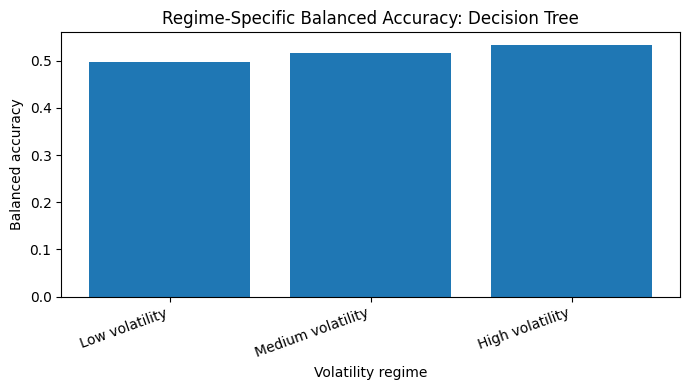

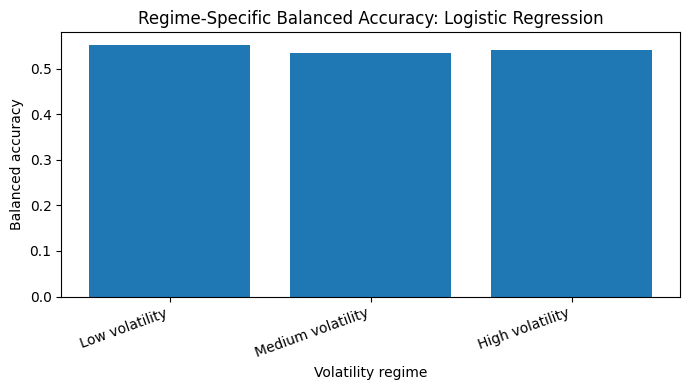

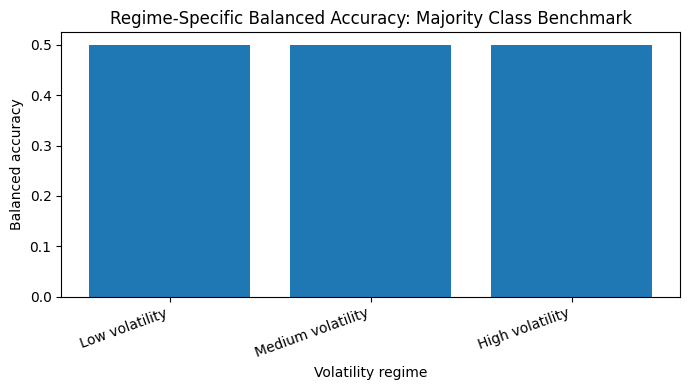

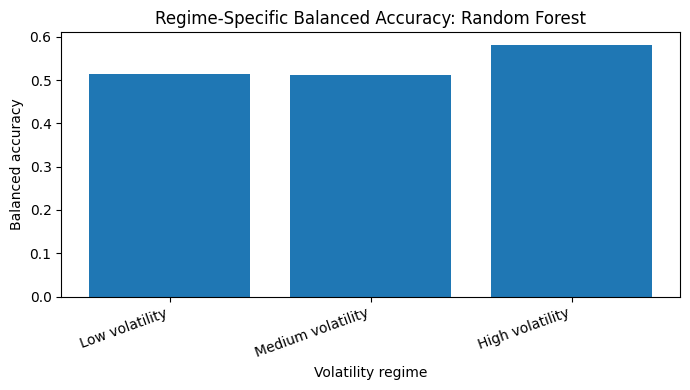

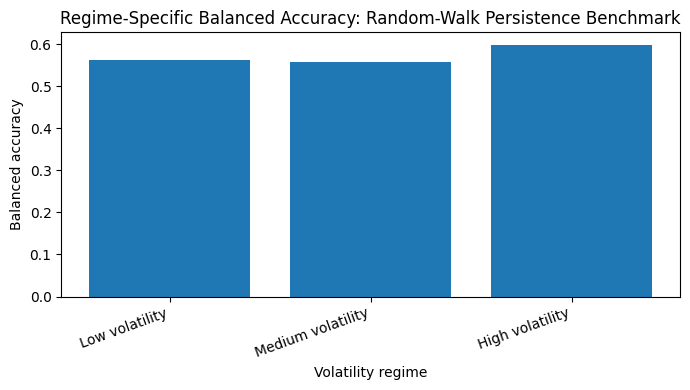

In [16]:
# GitHub-ready combined regime-specific performance plot
pivot_regime_plot = regime_results.pivot_table(
    index="model",
    columns="regime",
    values="balanced_accuracy",
    aggfunc="mean",
)

ax = pivot_regime_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Regime-Specific Balanced Accuracy by Model")
plt.ylabel("Balanced accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Volatility regime")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "regime_specific_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_DIR / 'regime_specific_accuracy.png'}")


## 12. Rolling-Window Validation

Rolling-window validation tests whether model performance is stable over time. This is important in non-stationary environments where a model that works in one period may fail in another.

In [17]:
# ============================================================
# 12. Rolling-Window Validation
# ============================================================

def rolling_window_validation(df, feature_cols, models, train_window=None, test_window=None, step=None):
    n = len(df)
    if train_window is None:
        train_window = min(1500, max(300, int(n * 0.50)))
    if test_window is None:
        test_window = min(300, max(100, int(n * 0.10)))
    if step is None:
        step = test_window

    rows = []
    fold = 0

    for start in range(0, n - train_window - test_window + 1, step):
        fold += 1
        train = df.iloc[start:start + train_window]
        test = df.iloc[start + train_window:start + train_window + test_window]

        # Benchmarks
        base = evaluate_baselines(train, test)
        for _, r in base.iterrows():
            rows.append({
                "fold": fold,
                "model": r["model"],
                "accuracy": r["accuracy"],
                "balanced_accuracy": r["balanced_accuracy"],
                "f1": r["f1"],
                "roc_auc": r["roc_auc"],
                "test_start": test.index.min(),
                "test_end": test.index.max(),
            })

        X_train, y_train = train[feature_cols], train["target_direction"]
        X_test, y_test = test[feature_cols], test["target_direction"]

        for name, model in models.items():
            clf = clone(model)
            clf.fit(X_train, y_train)
            pred = clf.predict(X_test)
            score = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None
            m = classification_metrics(y_test, pred, score)
            rows.append({
                "fold": fold,
                "model": name,
                **m,
                "test_start": test.index.min(),
                "test_end": test.index.max(),
            })

    return pd.DataFrame(rows)

rolling_results = rolling_window_validation(model_data, feature_cols, models)
rolling_results.head()

,fold,model,accuracy,balanced_accuracy,f1,roc_auc,test_start,test_end
0,1,Majority Class Benchmark,0.503425,0.500000,0.669704,NaN,2021-01-09 17:30:00,2021-01-10 17:45:00
1,1,Random-Walk Persistence Benchmark,0.517123,0.517124,0.518771,NaN,2021-01-09 17:30:00,2021-01-10 17:45:00
2,1,Logistic Regression,0.523973,0.524255,0.505338,0.564344,2021-01-09 17:30:00,2021-01-10 17:45:00
3,1,Decision Tree,0.561644,0.561623,0.564626,0.607835,2021-01-09 17:30:00,2021-01-10 17:45:00
4,1,Random Forest,0.554795,0.554727,0.560811,0.572085,2021-01-09 17:30:00,2021-01-10 17:45:00


In [18]:
if rolling_results.empty:
    print("Not enough observations for rolling-window validation.")
else:
    rolling_summary = rolling_results.groupby("model").agg(
        folds=("fold", "nunique"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        std_balanced_accuracy=("balanced_accuracy", "std"),
        min_balanced_accuracy=("balanced_accuracy", "min"),
        max_balanced_accuracy=("balanced_accuracy", "max"),
    ).sort_values("mean_balanced_accuracy", ascending=False)

    if SAVE_OUTPUTS:
        rolling_results.to_csv(OUTPUT_DIR / "rolling_window_results.csv", index=False)
        rolling_summary.to_csv(OUTPUT_DIR / "rolling_window_summary.csv")

    display(rolling_summary)

,folds,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,max_balanced_accuracy
model,,,,,
Random-Walk Persistence Benchmark,5,0.553499,0.034148,0.517124,0.604852
Logistic Regression,5,0.538081,0.018643,0.516239,0.558920
Random Forest,5,0.535412,0.032102,0.498190,0.566479
Decision Tree,5,0.502037,0.042293,0.454735,0.561623
Majority Class Benchmark,5,0.500000,0.000000,0.500000,0.500000


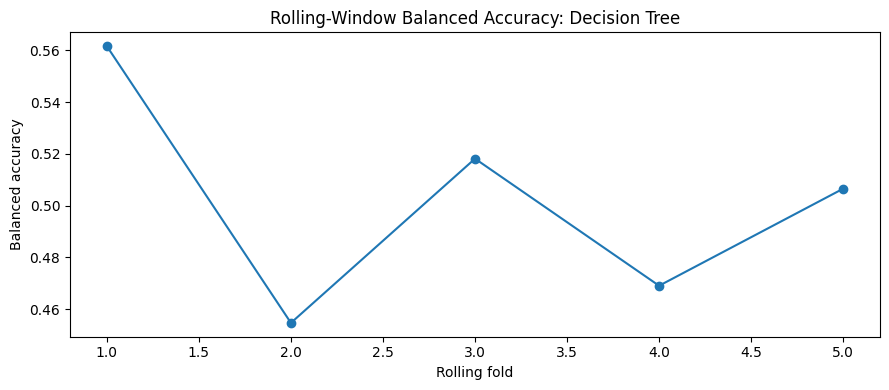

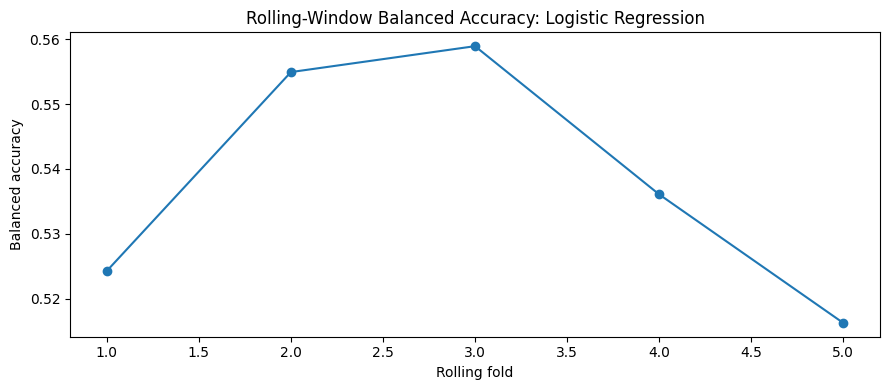

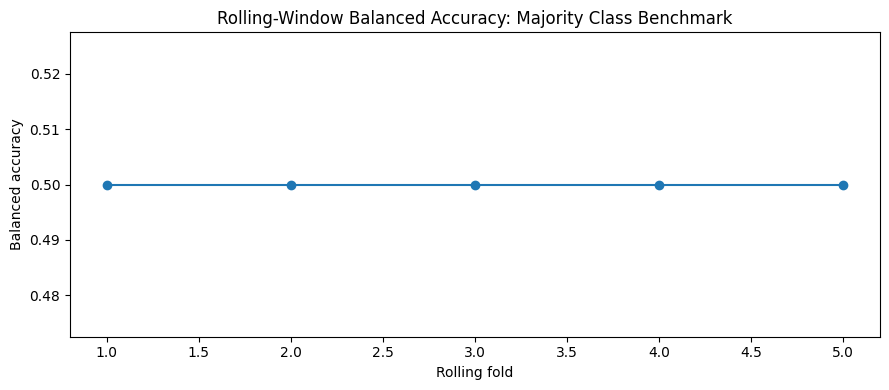

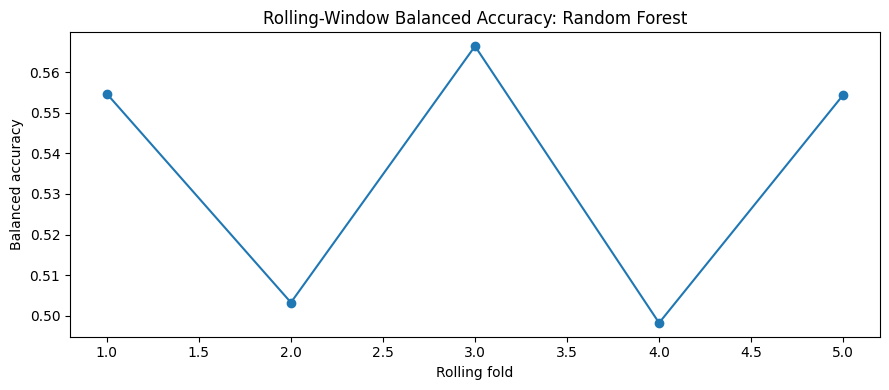

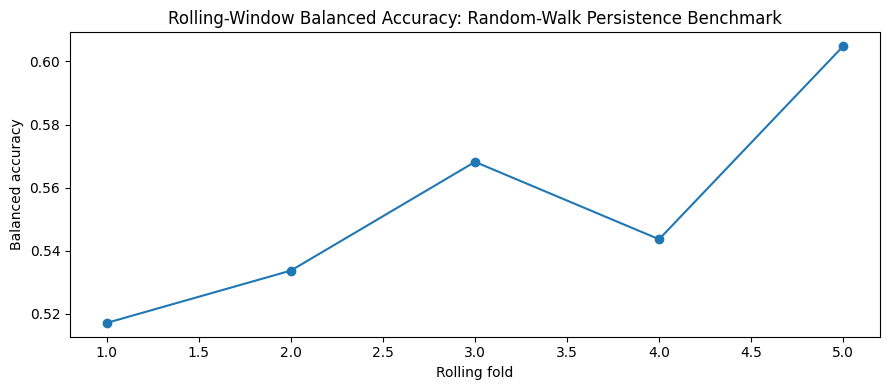

In [19]:
if not rolling_results.empty:
    pivot_rolling_plot = rolling_results.pivot_table(
        index="fold",
        columns="model",
        values="balanced_accuracy",
        aggfunc="mean",
    )

    ax = pivot_rolling_plot.plot(figsize=(12, 6), marker="o")
    plt.title("Rolling-Window Balanced Accuracy by Model")
    plt.ylabel("Balanced accuracy")
    plt.xlabel("Rolling window fold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "rolling_window_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {FIGURE_DIR / 'rolling_window_accuracy.png'}")
else:
    print("Not enough observations for rolling-window validation.")


## 13. Feature Importance and Interpretation

For tree-based models, feature importance helps explain which uncertainty and market features contribute most to predictive decisions.

,feature,importance
0,ret_lag_24,0.202273
1,ret,0.185380
2,ret_lag_1,0.116224
3,range_pct,0.111402
4,rolling_skew_ret_6,0.081038
5,rolling_std_ret_24,0.063151
6,rolling_skew_ret_72,0.059013
7,rolling_abs_ret_24,0.047055
8,Gold_ret,0.041510
9,range_pct_lag_1,0.040955


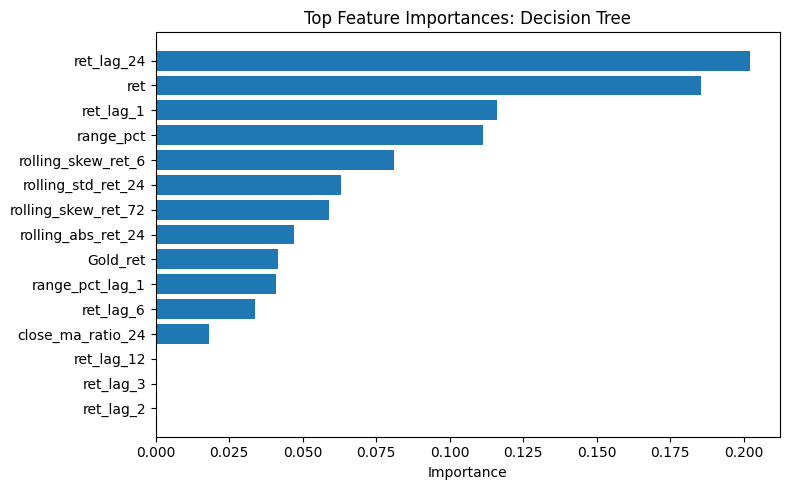

,feature,importance
0,ret,0.082631
1,close_ma_ratio_6,0.036988
2,ret_lag_24,0.035771
3,Crude_ret,0.032456
4,rolling_std_ret_72,0.030770
5,VIX_ret,0.030752
6,ret_lag_2,0.030071
7,Gold_ret,0.027855
8,range_pct,0.027623
9,ret_lag_1,0.026703


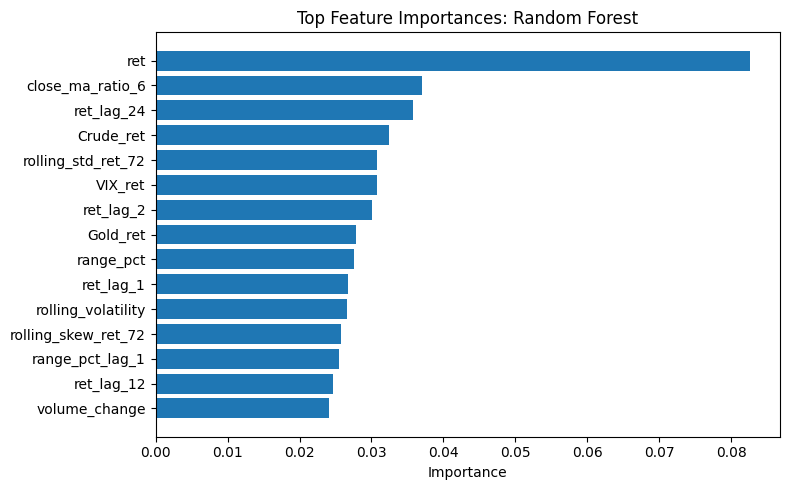

In [20]:
# ============================================================
# 13. Feature Importance
# ============================================================

def extract_feature_importance(fitted_model, feature_cols, top_n=15):
    """
    Extract feature importance for models that expose feature_importances_.
    """
    model = fitted_model
    if hasattr(model, "named_steps") and "clf" in model.named_steps:
        model = model.named_steps["clf"]

    if not hasattr(model, "feature_importances_"):
        return None

    importance = pd.Series(model.feature_importances_, index=feature_cols)
    return importance.sort_values(ascending=False).head(top_n)

for model_name in ["Decision Tree", "Random Forest"]:
    importance = extract_feature_importance(fitted_models[model_name], feature_cols)
    if importance is not None:
        display(pd.DataFrame({"feature": importance.index, "importance": importance.values}))
        plt.figure(figsize=(8, 5))
        plt.barh(importance.sort_values().index, importance.sort_values().values)
        plt.title(f"Top Feature Importances: {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()
        safe_name = model_name.lower().replace(" ", "_")
        plt.savefig(FIGURE_DIR / f"feature_importance_{safe_name}.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {FIGURE_DIR / f'feature_importance_{safe_name}.png'}")


## 14. Research Interpretation

This notebook reframes the project from a simple prediction exercise into an applied research study on model reliability.

### Research framing

Rather than asking, *Can machine learning predict stock prices?*, this project asks:

> How does predictive reliability change across uncertainty regimes, and can model performance remain stable under non-stationary market conditions?

### Why this matters

In many decision-making contexts, especially operations and service systems, predictive models are used to support decisions under uncertainty. A model that performs well on average may still be unreliable during high-uncertainty periods. Therefore, regime-specific evaluation and rolling validation provide a more realistic view of whether the model can support decision-making.

### Connection to OM / OR PhD interests

This project demonstrates research skills relevant to:

- predictive decision-making under uncertainty;
- non-stationary data-generating processes;
- model robustness and validation;
- regime-dependent performance analysis;
- empirical machine learning for operational decision support.

In [21]:
# ============================================================
# 14. Final Research Summary Table
# ============================================================

summary_items = {
    "Research question": "How stable are directional prediction models across uncertainty regimes?",
    "Primary uncertainty measure": feature_data["volatility_proxy_source"].dropna().iloc[-1] if "volatility_proxy_source" in feature_data else "Not available",
    "Number of observations": len(model_data),
    "Number of features": len(feature_cols),
    "Best model by test balanced accuracy": combined_results.sort_values("test_balanced_accuracy", ascending=False).iloc[0]["model"],
    "Best test balanced accuracy": round(combined_results["test_balanced_accuracy"].max(), 4),
    "Rolling validation folds": 0 if rolling_results.empty else int(rolling_results["fold"].nunique()),
}

research_summary = pd.DataFrame(summary_items.items(), columns=["Item", "Value"])
research_summary

,Item,Value
0,Research question,How stable are directional prediction models a...
1,Primary uncertainty measure,EWMA_fallback
2,Number of observations,2928
3,Number of features,43
4,Best model by test balanced accuracy,Random-Walk Persistence Benchmark
5,Best test balanced accuracy,0.574
6,Rolling validation folds,5


## 15. CV / GitHub Description

You can use the following description in your resume, CV, or GitHub README.

**Regime-Dependent Prediction under Financial Market Uncertainty**  
Designed a research-oriented machine learning framework to evaluate directional prediction reliability under changing market regimes. Built volatility-based uncertainty proxies, including an LSTM-based sequence model with EWMA fallback, and compared logistic regression, decision tree, and random forest models against majority-class and random-walk benchmarks. Evaluated performance across low-, medium-, and high-volatility regimes and implemented rolling-window validation to test robustness under non-stationarity. Reframed the project from stock-price prediction toward uncertainty-aware predictive decision-making, model reliability, and empirical validation.

## 16. GitHub Figure Outputs

Running this notebook saves the key GitHub-ready figures to the `figures/` folder:

```text
figures/model_performance_comparison.png
figures/regime_specific_accuracy.png
figures/rolling_window_accuracy.png
figures/overfitting_gap.png
```

These can be referenced directly in `README.md` using Markdown image links.
